# 날씨데이터로 RNN 실습

## 1. 패키지 설정

In [37]:
import pandas as pd
from matplotlib import pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

## 2. 데이터 불러오기

In [38]:
with open("data.csv") as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


## 3. 데이터 전처리

### 3-1. 데이터 파싱

불필요하다고 판단되는 날짜 데이터를 제거

In [39]:
# 코드 10-2 데이터 파싱
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]  # 두 번째 열을 'temperature' 배열에 저장합니다.
    raw_data[i, :] = values[:]  # (온도를 포함하여) 모든 열을 'raw_data' 배열에 저장합니다.

### 3-2. 훈련,검증,테스트 데이터 분리 개수 확인

In [40]:
# ============ 데이터 분할 개수 확인 ============
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


### 3-3. 데이터 정규화

평균 0, 분산 1로 정규화  
데이터 누수를 방지하기 위해 훈련 데이터만 정규화

In [41]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

### 3-4. 데이터셋 생성

In [42]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

In [43]:
train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

## 4. 모델 정의

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras",
                                    save_best_only=True)
]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - loss: 70.4656 - mae: 6.4174 - val_loss: 12.4301 - val_mae: 2.6655
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - loss: 11.8762 - mae: 2.6526 - val_loss: 9.6487 - val_mae: 2.4089
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - loss: 9.6953 - mae: 2.4264 - val_loss: 9.6191 - val_mae: 2.4182
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - loss: 9.2028 - mae: 2.3606 - val_loss: 9.8043 - val_mae: 2.4452
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - loss: 8.9005 - mae: 2.3235 - val_loss: 10.0020 - val_mae: 2.4746
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - loss: 8.6761 - mae: 2.2933 - val_loss: 10.0392 - val_mae: 2.4787
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - loss: 8.4929 - mae: 2.2704 - val_loss: 9.8822 - val_mae: 2.4670
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - loss: 8.3358 - mae: 2.2498 - val_loss: 9.9792 - val_mae: 2.4743
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━

## 5. 모델 학습

In [ ]:
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_lstm.keras")
print(f"테스트 MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 10.8632 - mae: 2.5764
테스트 MAE: 2.58


## 6. 학습 결과 시각화

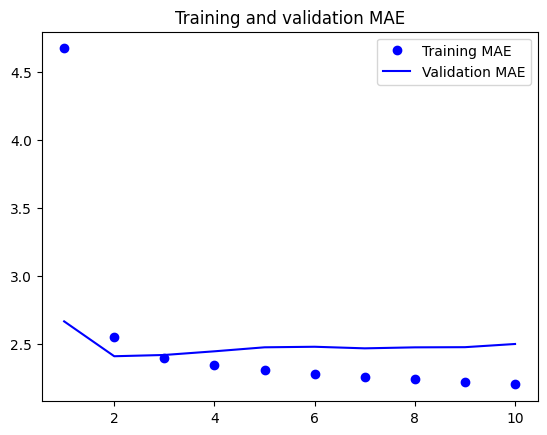

In [46]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()